# SETUP

In [1]:
!pip install transformers==5.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.9 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install evaluate rouge_score bert_score Sastrawi unsloth datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.2/403.2 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install -U bitsandbytes

In [2]:
!pip show transformers trl unsloth

Name: transformers
Version: 5.3.0
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\users\lenovo\anaconda3\envs\dlenv\lib\site-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: bert-score, llm-blender, mergekit, parler_tts, peft, sentence-transformers, trl, unsloth, unsloth_zoo
---
Name: trl
Version: 0.24.0
Summary: Train transformer language models with reinforcement learning.
Home-page: https://github.com/huggingface/trl
Author: 
Author-email: Leandro von Werra <leandro.vonwerra@gmail.com>
License-Express

In [2]:
import pandas as pd
import numpy as np
import random
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from PIL import Image
import re
from tqdm import tqdm
import cv2
import os
import string
from collections import Counter
from functools import partial
from textwrap import wrap
import textwrap as tw
from warnings import filterwarnings
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW, AdamW
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_

from torchvision.transforms import v2
from torchvision.models import inception_v3, Inception_V3_Weights, ResNet50_Weights, resnet50
import evaluate
from pycocoevalcap.cider.cider import Cider
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig, Seq2SeqTrainingArguments, Seq2SeqTrainer, GPT2Tokenizer, Dinov2Model, get_scheduler, AutoProcessor, AutoModelForCausalLM, BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model

from unsloth import FastVisionModel
from trl import SFTTrainer, SFTConfig
from unsloth import UnslothVisionDataCollator, is_bfloat16_supported

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

filterwarnings("ignore")
SEED=42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(SEED)


c:\Users\LENOVO\anaconda3\envs\dlenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LENOVO\anaconda3\envs\dlenv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
W0413 12:59:44.761000 22748 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22748\3766715511.py:37: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


# DATASET

## Kaggle Path

In [3]:
TRAIN_METADATA_PATH = "/kaggle/input/datasets/abidalfaridzi/metadata-vw/Train.csv"
VAL_METADATA_PATH = "/kaggle/input/datasets/abidalfaridzi/metadata-vw/Val.csv"
TEST_ANNOTATION_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/test.json"
TRAIN_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/train/train"
VAL_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/val/val"

## Local

In [4]:
TRAIN_METADATA_PATH = "../data/Train.csv"
VAL_METADATA_PATH = "../data/Val.csv"
TEST_ANNOTATION_PATH = "../data/annotations/test.json"
TRAIN_IMG_PATH = "../data/train"
VAL_IMG_PATH = "../data/val"

In [5]:
train_df = pd.read_csv(TRAIN_METADATA_PATH)
print(f"Number of training samples: {len(train_df)}")
display(train_df.head())

val_df = pd.read_csv(VAL_METADATA_PATH)
print(f"\nNumber of validation samples: {len(val_df)}")
display(val_df.head())

with open(TEST_ANNOTATION_PATH, "r") as f:
    test_data = json.load(f)
test_df = pd.DataFrame(test_data['images'])
print(f"\nNumber of test samples: {len(test_df)}")
display(test_df.head())

Number of training samples: 117155


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True,INI ADALAH WADAH DAUN BASIL YANG MENUNJUKKAN B...
1,A green and white plastic condiment bottle con...,0,False,False,1,True,Botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,0,True,True,2,True,Masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,0,False,False,3,True,Sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,0,False,False,4,True,beberapa lembar daun basil dalam wadah di atas...



Number of validation samples: 38750


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,A computer screen shows a repair prompt on the...,23431,False,False,117155,True,Layar komputer menampilkan perintah perbaikan.
1,a computer screen with a repair automatically ...,23431,False,False,117156,True,Layar komputer dengan pesan perbaikan yang mun...
2,partial computer screen showing the need of re...,23431,False,False,117157,True,Sebagian layar komputer menunjukkan perlunya p...
3,Part of a computer monitor showing a computer ...,23431,False,False,117158,True,Bagian dari monitor komputer yang menampilkan ...
4,The top of a laptop with a blue background and...,23431,False,False,117159,True,Bagian atas laptop dengan latar belakang biru ...



Number of test samples: 8000


,file_name,vizwiz_url,id,text_detected
0,VizWiz_test_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31181,True
1,VizWiz_test_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31182,False
2,VizWiz_test_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31183,True
3,VizWiz_test_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31184,True
4,VizWiz_test_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31185,True


In [6]:
unq_id = sorted([int(i.split("_")[2].split(".")[0]) for i in os.listdir(VAL_IMG_PATH)])
max_val_id = max(unq_id)
new_val_id = [i for i in range(max_val_id + 1) for j in range(5)]
val_df['image_id'] = new_val_id

In [18]:
print("Total missing value in train:")
display(train_df.isnull().sum())

print("\nTotal missing value in val:")
display(val_df.isnull().sum())

print("\nTotal missing value in test:")
display(test_df.isnull().sum())

Total missing value in train:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in val:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in test:


file_name        0
vizwiz_url       0
id               0
text_detected    0
dtype: int64

In [7]:
print(f"Total duplicate in train: {train_df.duplicated().sum()}")
print(f"Total duplicate in val: {val_df.duplicated().sum()}")
print(f"Total duplicate in test: {val_df.duplicated().sum()}")

Total duplicate in train: 0
Total duplicate in val: 0
Total duplicate in test: 0


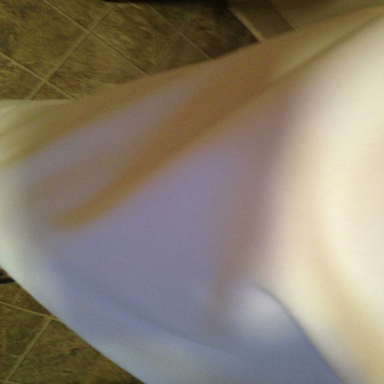

In [9]:
def display_single_image(image_id):
    image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{image_id:08d}.jpg")
    image = Image.open(image_path).resize((384, 384))
    display(image)
display_single_image(train_df.loc[train_df['image_id'] == 15, 'image_id'].values[0])

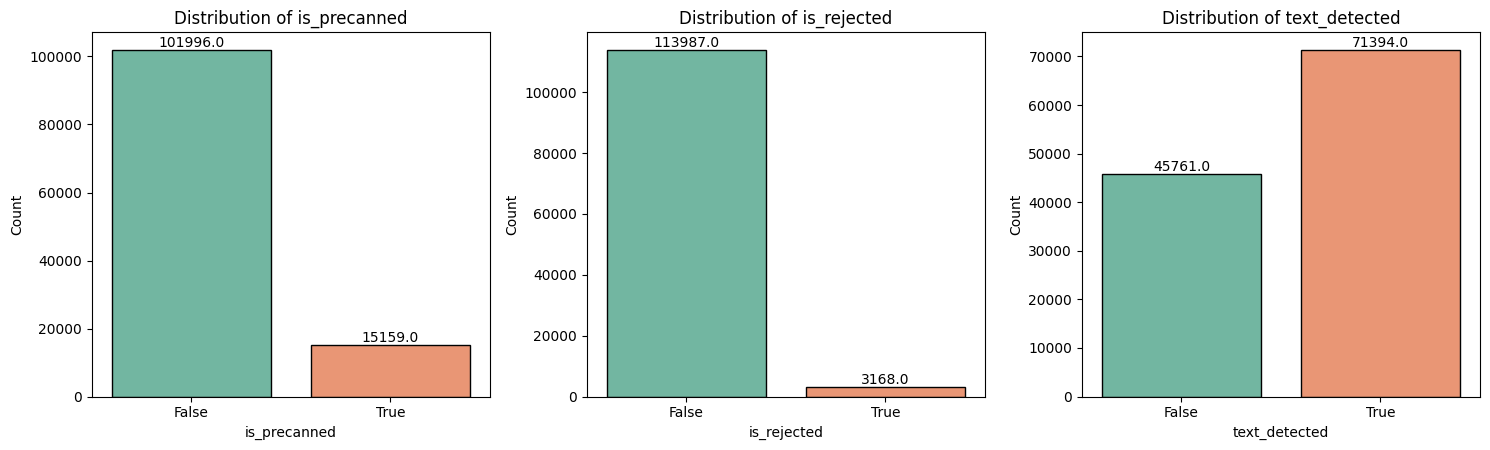

In [ ]:
def cols_distribution(df, columns):
    length = len(columns)
    cols = 3
    rows = length // cols + (length % cols > 0)
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, col in enumerate(columns):
        plt.subplot(rows, cols, i + 1)
        ax =sns.countplot(x=col, data=df, palette='Set2', edgecolor='black')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
cols_distribution(train_df, ['is_precanned', 'is_rejected', 'text_detected'])

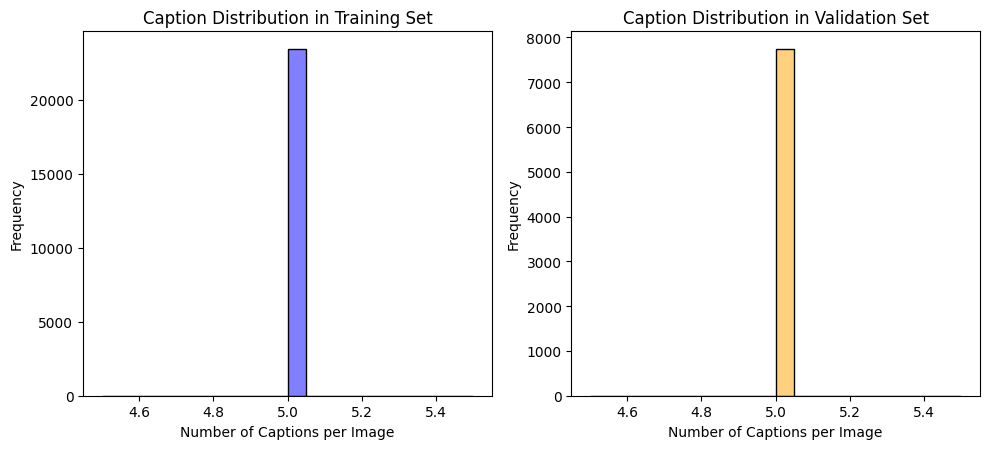

In [ ]:
def captions_distribution(train, val):
    cols, rows = 2, 1
    plt.figure(figsize=(5 * cols, 5 * rows))
    plt.subplot(rows, cols, 1)
    train_dist = train.groupby('image_id')['caption'].count()
    sns.histplot(train_dist, bins=20, kde=True, color='blue', edgecolor='black')
    plt.title("Caption Distribution in Training Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.subplot(rows, cols, 2)
    val_dist = val.groupby('image_id')['caption'].count()
    sns.histplot(val_dist, bins=20, kde=True, color='orange', edgecolor='black')
    plt.title("Caption Distribution in Validation Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
captions_distribution(train_df, val_df)


=> every image has 5 captions

Image ID: 20952


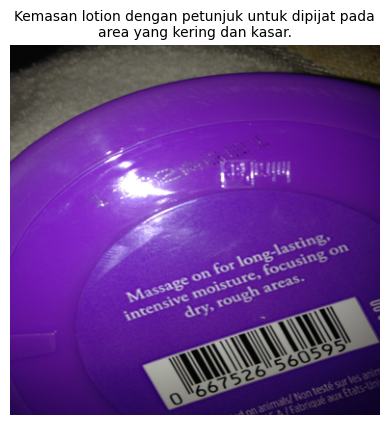

Image ID: 3648


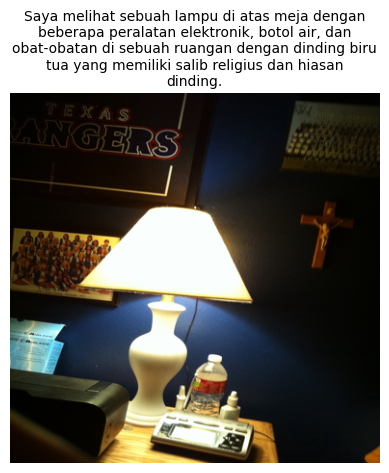

Image ID: 819


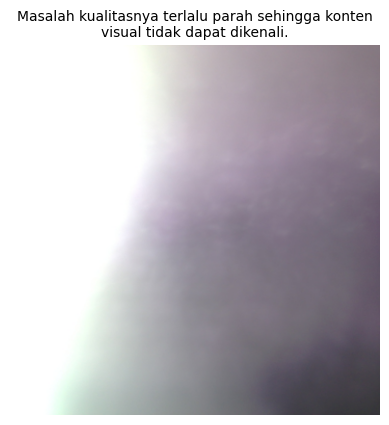

Image ID: 9012


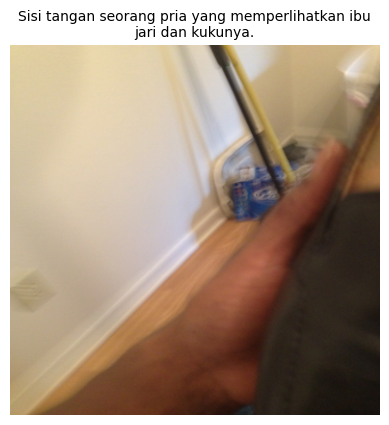

Image ID: 8024


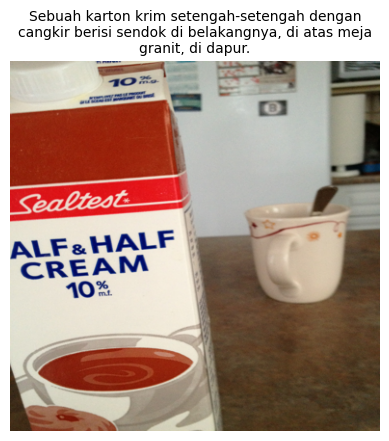

In [ ]:
def display_image_captions(df, n_samples=5):
    random_idxs = random.sample(list(df['image_id'].unique()), n_samples)
    for idx in random_idxs:
        image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{idx:08d}.jpg")
        image = Image.open(image_path).resize((384, 384))
        captions = df[df['image_id'] == idx]['caption_id'].values[0]
        print(f"Image ID: {idx}")
        plt.imshow(image)
        plt.axis('off')
        plt.title("\n".join(wrap(captions, width=50)), fontsize=10)
        plt.show()
display_image_captions(train_df, n_samples=5)




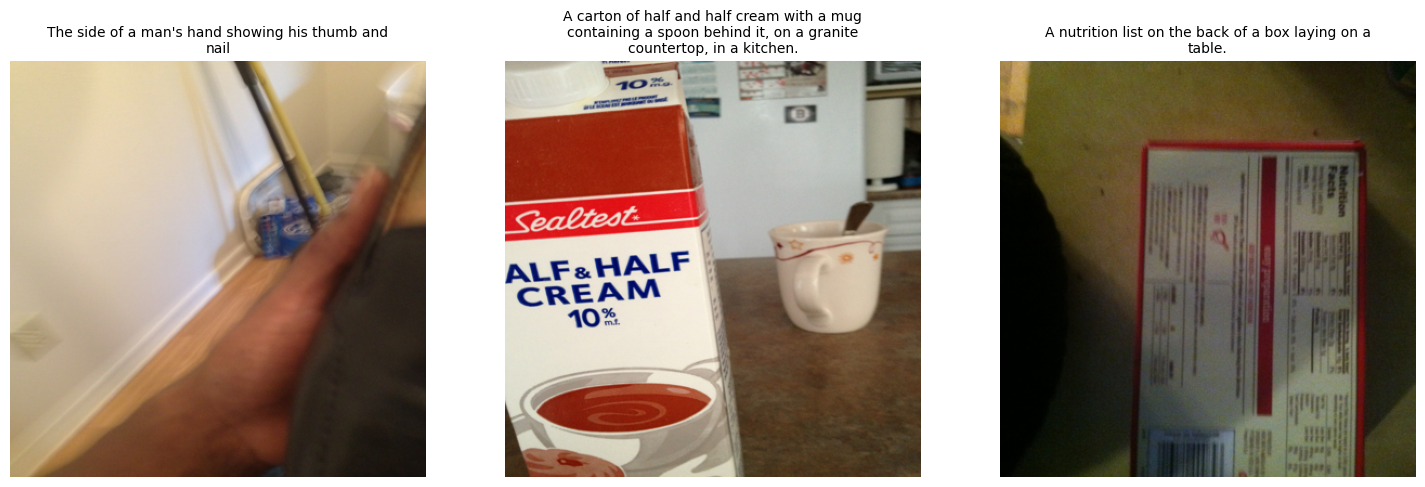

In [8]:
def display_image_captions_mat(df, n_samples=5):
    random_idxs = random.sample(list(df['image_id'].unique()), n_samples)
    cols, rows = 3, (n_samples + 1) // 2
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, idx in enumerate(random_idxs):
        image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{idx:08d}.jpg")
        image = Image.open(image_path).resize((384, 384))
        captions = df[df['image_id'] == idx]['caption'].values[0]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title("\n".join(wrap(captions, width=50)), fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])   
display_image_captions_mat(train_df, n_samples=3)

In [19]:
def preprocess_caption(caption):
    caption = caption.lower()
    punc = string.punctuation.replace("'", "")
    caption = re.sub(f"[{re.escape(punc)}]", " ", caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption
train_df['cleaned_caption'] = train_df['caption_id'].apply(preprocess_caption)
val_df['cleaned_caption'] = val_df['caption_id'].apply(preprocess_caption)
display(train_df[['caption', 'cleaned_caption']].head())

,caption,cleaned_caption
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,ini adalah wadah daun basil yang menunjukkan b...
1,A green and white plastic condiment bottle con...,botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,beberapa lembar daun basil dalam wadah di atas...


In [20]:
train_df['image_id'] = train_df['image_id'].apply(lambda x: f"VizWiz_train_{x:08d}.jpg")
val_df['image_id'] = val_df['image_id'].apply(lambda x: f"VizWiz_val_{x:08d}.jpg")

In [21]:
max_len_train = train_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len_val = val_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len = max(max_len_train, max_len_val)
print(f"Max caption length in training set: {max_len_train}")
print(f"Max caption length in validation set: {max_len_val}")
print(f"Overall max caption length: {max_len}")

Max caption length in training set: 106
Max caption length in validation set: 145
Overall max caption length: 145


In [22]:
# pakai 1 img aj
grouped_captions_val = val_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
grouped_captions_train = train_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
val_df = val_df.drop_duplicates(subset=['image_id']).reset_index(drop=True)
val_df.shape

(7750, 8)

In [10]:
def print_param(model, stage_name=""):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    all_params = sum(p.numel() for p in model.parameters())
    print(f"--- {stage_name} ---")
    print(f"Trainable params : {trainable_params:,}")
    print(f"Total params     : {all_params:,}")
    print(f"% Trainable      : {100 * trainable_params / all_params:.4f}%\n")

# MODEL

## QWEN3VL

In [5]:
gc.collect()
torch.cuda.empty_cache()

### Zero-Shot

In [1]:
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "Qwen/Qwen3-VL-4B-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    gpu_memory_utilization=0.9,
)

NameError: name 'FastVisionModel' is not defined

In [ ]:
from io import BytesIO
def compress_image(image_path, max_size=720, quality=85):
    image = Image.open(image_path).convert("RGB")

    image.thumbnail((max_size, max_size), Image.LANCZOS)

    buffer = BytesIO()
    
    image.save(buffer, format="JPEG", quality=quality, optimize=True)
    buffer.seek(0)
    compressed = Image.open(buffer).convert("RGB")

    print(f"Compressed size: {compressed.size}")
    return compressed

Compressed size: (540, 720)


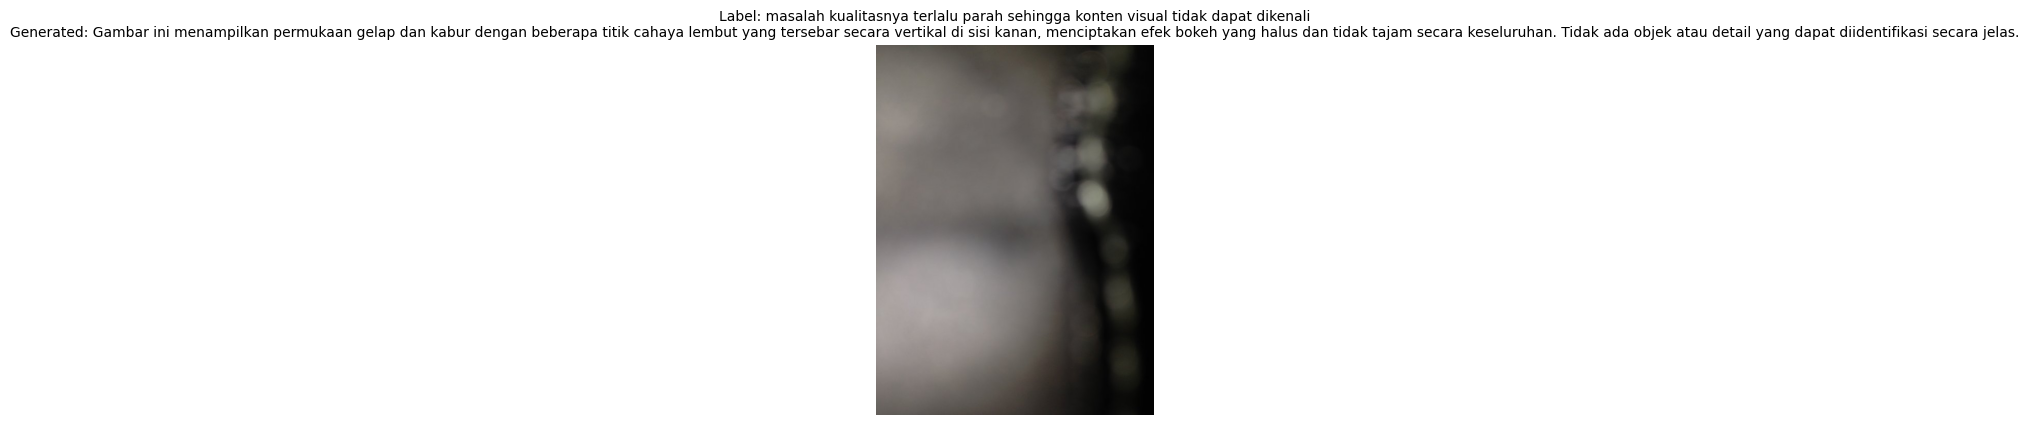

In [ ]:
def generate_final_caption(image, device, qwen_model, qwen_tokenizer, max_gen_len=512):
    FastVisionModel.for_inference(qwen_model)
    instruction = (
        "Deskripsikan gambar ini secara objektif untuk tunanetra. "
        f"Berikan deskripsi akhir yang objektif, jelas,lengkap, dan siap dibacakan "
        f"oleh mesin TTS di antara dalam satu hingga dua kalimat."
    )
    
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]},
    ]

    inputs_text = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True
    )

    inputs = qwen_tokenizer(
        image,
        inputs_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to(device)

    with torch.no_grad():
        with autocast():
            generated_ids = qwen_model.generate(
                **inputs, 
                max_new_tokens=max_gen_len,
                do_sample=False, 
                num_beams=5,    
                repetition_penalty=1.15, 
                no_repeat_ngram_size=3 
            )
    
    input_len = inputs.input_ids.shape[1]
    generated_new_ids = generated_ids[:, input_len:]
    
    refined_caption = qwen_tokenizer.batch_decode(generated_new_ids, skip_special_tokens=True)[0]
    
    return refined_caption.strip() if refined_caption.strip() != "" else "unk"

image_path = "OIP (1).jpg"
image = Image.open(image_path).convert("RGB")
image = compress_image(image_path, max_size=720, quality=85)
label = grouped_captions_val[os.path.basename(image_path)][0]
final_caption = generate_final_caption(image, device="cuda", qwen_model=model, qwen_tokenizer=tokenizer)
plt.imshow(image)
plt.axis('off')
plt.title(f"Label: {label}\nGenerated: {final_caption}", fontsize=10)
plt.show()


### Fine tuned

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = False,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0.05,
    bias = "none",
    random_state = 3407,
)

FastVisionModel.for_training(model)

In [ ]:
from datasets import Dataset as HFDataset

instruction = (
    "You are a Visual Assistant specializing in accessibility. Analyze this image meticulously "
    "to help visually impaired users understand its content.\n"
    "Guidelines:\n"
    "1. Factual & Objective: Focus on main elements, people, activities, colors, visible text, "
    "and spatial layout (left, right, foreground, background). "
    "Avoid assumptions or interpretations that cannot be visually confirmed.\n"
    "2. Blurry Image: If the image is entirely unrecognizable, output only: "
    "'Mohon ambil gambar ulang.'\n"
    "3. Output Format (CRITICAL): Write the entire description as EXACTLY ONE single continuous "
    "sentence in Bahasa Indonesia. Use conjunctions such as 'yang', 'dengan', 'serta', 'dan', "
    "'di mana', 'sambil' to connect all details smoothly. "
    "There must be ONLY ONE period (.) and it must be at the very end. "
    "Do not include any introduction, greeting, or closing remark."
)

BROKEN_FLAG      = "masalah kualitasnya terlalu parah sehingga konten visual tidak dapat dikenali"
BROKEN_THRESHOLD = 4


def select_best_caption(captions) :
    return max(captions, key=lambda c: len(set(c.lower().split())))


def convert_to_conversation(image_id, grouped_captions, image_dir):
    full_image_path = f"{image_dir}/{image_id}"
    broken_count = sum(1 for c in grouped_captions if BROKEN_FLAG in c)

    if broken_count >= BROKEN_THRESHOLD:
        final_caption = BROKEN_FLAG + "."
    else:
        valid = [
            c.strip().rstrip(".")
            for c in grouped_captions
            if BROKEN_FLAG not in c and c.strip()
        ]
        final_caption = select_best_caption(valid) + "."

    return {"messages": [
        {"role": "user", "content": [
            {"type": "text",  "text":  instruction},
            {"type": "image", "image": full_image_path},
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": final_caption},
        ]},
    ]}


train_python_list = [convert_to_conversation(iid, caps, TRAIN_IMG_PATH)
                     for iid, caps in grouped_captions_train.items()]
val_python_list   = [convert_to_conversation(iid, caps, VAL_IMG_PATH)
                     for iid, caps in grouped_captions_val.items()]

hf_train_dataset = HFDataset.from_list(train_python_list)
hf_val_dataset   = HFDataset.from_list(val_python_list)

print(f"Train: {len(hf_train_dataset)} | Val: {len(hf_val_dataset)}")
for i in range(min(3, len(hf_train_dataset))):
    print(f"\n[{i}]", hf_train_dataset[i]["messages"][1]["content"][0]["text"])

multi = []
for item in train_python_list:
    cap = item["messages"][1]["content"][0]["text"]
    sentences = [s for s in cap.split(".") if s.strip()]
    if len(sentences) > 1:
        multi.append(cap)

print(f"\nMulti-sentence captions in train: {len(multi)} / {len(train_python_list)}")
if multi:
    for m in multi[:3]:
        print(" →", m)

Train: 23431 | Val: 7750

[0] botol bumbu plastik berwarna hijau dan putih berisi daun basil.

[1] sebuah kaleng coca cola di atas meja ditampilkan untuk saat seseorang membutuhkan minuman dingin yang menyegarkan.

[2] sebuah kaleng tomat hancur berada di atas permukaan berwarna cokelat tomat tersebut bertuliskan tomat hancur pada mereknya.

Multi-sentence captions in train: 0 / 23431


In [15]:
grouped_captions_train

{'VizWiz_train_00000000.jpg': ['ini adalah wadah daun basil yang menunjukkan berat bersihnya.',
  'botol bumbu plastik berwarna hijau dan putih berisi daun basil.',
  'masalah kualitasnya terlalu parah sehingga konten visual tidak dapat dikenali.',
  'sebotol bumbu dalam wadah plastik tergeletak di permukaan.',
  'beberapa lembar daun basil dalam wadah di atas meja.'],
 'VizWiz_train_00000001.jpg': ['sebuah kaleng coca cola di atas meja ditampilkan untuk saat seseorang membutuhkan minuman dingin yang menyegarkan.',
  'sebuah kaleng hitam coca cola tanpa kalori berada di atas meja dekat mesin kopi.',
  'meja dapur dengan berbagai barang di atasnya termasuk sekaleng coca cola wadah logam dan teko.',
  'kaleng coca cola hitam diletakkan di atas permukaan hitam.',
  'meja hitam dengan wadah wadah teko dan sekaleng soda.'],
 'VizWiz_train_00000002.jpg': ['sebuah kaleng tomat hancur berada di atas permukaan berwarna cokelat tomat tersebut bertuliskan tomat hancur pada mereknya.',
  'sebuah k

In [ ]:
data_collator = UnslothVisionDataCollator(model, tokenizer)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = hf_train_dataset,
    eval_dataset = hf_val_dataset,

    args = SFTConfig(
        per_device_train_batch_size = 2,
        per_device_eval_batch_size = 2,
        gradient_accumulation_steps = 4,
        # dataloader_prefetch_factor = 2,

        num_train_epochs = 3,
        eval_strategy = "epoch",
        # eval_steps = 50,
        save_strategy = "epoch",
        # save_steps = 50,
        # logging_steps = 10,

        learning_rate = 2e-4,
        warmup_steps = 50,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",

        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),

        output_dir = "outputs/viz2speech_qwen_checkpoints_2",
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",

        remove_unused_columns = False,

        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 512,
    ),
)

trainer_stats = trainer.train()

print(f"Training time: {trainer_stats.metrics['train_runtime']:.2f} s.")

Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 23,431 | Num Epochs = 3 | Total steps = 8,787
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,470,845,952 (0.74% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.128100,0.165453
2,0.119442,0.161245
3,0.111213,0.171324


Training time: 90230.89 s.


In [29]:
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

In [27]:
MODEL_PATH = "../models/KevinLM3VL"

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = MODEL_PATH,
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

FastVisionModel.for_inference(model)

==((====))==  Unsloth 2026.3.16: Fast Qwen3_Vl patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 713/713 [00:07<00:00, 101.07it/s]


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): Linear(in_features=1024, out_features=3072, bias=True)
                (proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (mlp): Qwen3VLVisionMLP(
                (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
               

Compressed size: (540, 720)


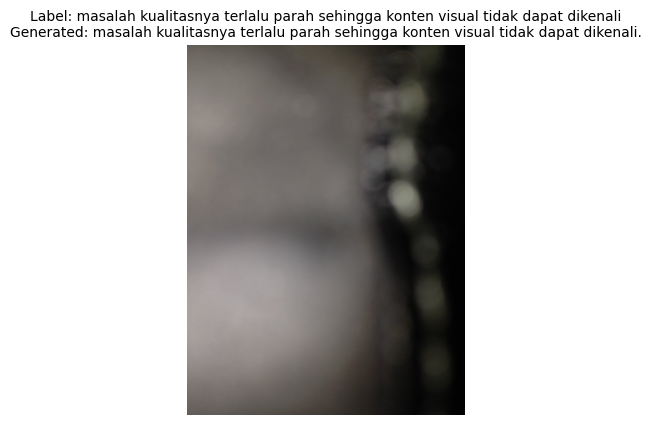

In [28]:
def generate_final_caption(image, device, qwen_model, qwen_tokenizer, max_gen_len=512):
    instruction = (
        "You are a Visual Assistant specializing in accessibility. Analyze this image meticulously "
        "to help visually impaired users understand its content.\n"
        "Guidelines:\n"
        "1. Factual & Objective: Focus on main elements, people, activities, colors, visible text, "
        "and spatial layout (left, right, foreground, background). "
        "Avoid assumptions or interpretations that cannot be visually confirmed.\n"
        "2. Blurry Image: If the image is entirely unrecognizable, output only: "
        "'Mohon ambil gambar ulang.'\n"
        "3. Output Format (CRITICAL): Write the entire description as EXACTLY ONE single continuous "
        "sentence in Bahasa Indonesia. Use conjunctions such as 'yang', 'dengan', 'serta', 'dan', "
        "'di mana', 'sambil' to connect all details smoothly. "
        "There must be ONLY ONE period (.) and it must be at the very end. "
        "Do not include any introduction, greeting, or closing remark."
    )

    instruction = (
        "Deskripsikan gambar ini secara objektif untuk tunanetra. "
        f"Berikan deskripsi akhir yang objektif, jelas,lengkap, dan siap dibacakan "
        f"oleh mesin TTS di antara dalam satu hingga dua kalimat."
    )
    
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]},
    ]

    inputs_text = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True
    )

    inputs = qwen_tokenizer(
        image,
        inputs_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to(device)

    with torch.no_grad():
        with autocast():
            generated_ids = qwen_model.generate(
                **inputs, 
                max_new_tokens=max_gen_len,
                do_sample=False, 
                num_beams=3,    
                repetition_penalty=1.15, 
                no_repeat_ngram_size=3 
            )
    
    input_len = inputs.input_ids.shape[1]
    generated_new_ids = generated_ids[:, input_len:]
    
    refined_caption = qwen_tokenizer.batch_decode(generated_new_ids, skip_special_tokens=True)[0]
    
    return refined_caption.strip() if refined_caption.strip() != "" else "unk"

image_path = "../data/val/VizWiz_val_00007680.jpg"
image = compress_image(image_path, max_size=720, quality=85)
label = grouped_captions_val[os.path.basename(image_path)][0]
final_caption = generate_final_caption(image, device="cuda", qwen_model=model, qwen_tokenizer=tokenizer)
plt.imshow(image)
plt.axis('off')
plt.title(f"Label: {label}\nGenerated: {final_caption}", fontsize=10)
plt.show()


In [ ]:
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")
generated_captions = dict()
def evaluate_model(model, tokenizer, test_df, image_dir, generated_captions={}):
    refs = []
    preds = []

    for image_id, refs in tqdm(grouped_captions_val.items(), desc="Evaluating"):
        image_path = os.path.join(image_dir, image_id)
        image = Image.open(image_path).convert("RGB")
        pred_caption = generate_final_caption(image, device="cuda", qwen_model=model, qwen_tokenizer=tokenizer)
        generated_captions[image_id] = pred_caption
        
        refs.append(refs)  # List of reference captions for this image
        preds.append(pred_caption)  # Generated caption for this image

        # empty cache setiap iterasi untuk mencegah OOM
        del image, pred_caption
        gc.collect()
        torch.cuda.empty_cache()


    refs_flat = [ref for sublist in refs for ref in sublist]
    bleu_score = bleu_metric.compute(predictions=preds, references=refs_flat)
    bertscore = bertscore_metric.compute(predictions=preds, references=refs_flat, lang="id")
    return bleu_score, bertscore, generated_captions
bleu_score, bertscore, generated_captions = evaluate_model(model, tokenizer, val_df, VAL_IMG_PATH)
print(f"BLEU Score: {bleu_score['bleu']:.4f}")
print(f"BERTScore - Precision: {bertscore['precision'].mean():.4f}, Recall: {bertscore['recall'].mean():.4f}, F1: {bertscore['f1'].mean():.4f}")

In [ ]:

gts = {}
res = {}

for img_id, gt_captions in grouped_captions_val.items():
    if img_id in generated_captions:
        gts[img_id] = gt_captions
        
        pred = generated_captions[img_id]
        if isinstance(pred, str):
            res[img_id] = [pred]
        else:
            res[img_id] = pred

cider_scorer = Cider()
avg_score, individual_scores = cider_scorer.compute_score(gts, res)

print(f"\nSkor CIDEr Rata-rata (Seluruh Dataset): {avg_score:.4f}\n")